# PDP data 연관성/EDA

In [6]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df = pd.read_csv('amz_pdp_price_sales_gv_top20_0617.csv')

In [28]:
df.head(5)

,crawl_date,asin,rating,ratings_cnt,salesrank1,salesrank2,salesrank3,bw_price,revenue,units,gv
0,2024-01-12,B0CKZ1CK1H,4.4,106587.0,56478.0,1534.0,NaN,349.00,349.00,1.0,277.0
1,2024-01-12,B0CKYY27YP,4.4,106587.0,18941.0,8.0,NaN,198.91,198.88,1.0,68.0
2,2024-01-12,B0CKYYL8B9,4.4,106587.0,1836649.0,4905.0,NaN,209.99,259.00,1.0,48.0
3,2024-01-13,B0CKZ1CK1H,4.4,152048.0,253.0,3.0,NaN,349.00,2443.00,7.0,351.0
4,2024-01-12,B0CKYZPPMJ,4.4,106587.0,1952729.0,80.0,NaN,151.12,151.11,1.0,167.0


In [30]:
# 날짜 컬럼이 문자열인 경우 datetime으로 변환
df['crawl_date'] = pd.to_datetime(df['crawl_date'])

In [32]:
print(df.dtypes)

crawl_date     datetime64[ns]
asin                   object
rating                float64
ratings_cnt           float64
salesrank1            float64
salesrank2            float64
salesrank3            float64
bw_price              float64
revenue               float64
units                 float64
gv                    float64
dtype: object


In [34]:
df.describe()

,crawl_date,rating,ratings_cnt,salesrank1,salesrank2,salesrank3,bw_price,revenue,units,gv
count,8868,8868.000000,8868.000000,8.866000e+03,8866.000000,17.000000,8868.000000,8868.000000,8868.000000,8868.000000
mean,2024-10-24 06:23:42.462787584,4.394441,100016.198128,3.424027e+04,67.614708,817.000000,174.644185,14359.092559,86.029544,1367.459517
min,2024-01-09 00:00:00,3.800000,2.000000,1.600000e+01,1.000000,5.000000,42.700000,-2699.910000,-16.000000,0.000000
25%,2024-07-02 00:00:00,4.300000,29813.000000,1.060000e+02,2.000000,9.000000,89.990000,1889.790000,13.000000,334.000000
50%,2024-10-29 00:00:00,4.400000,103787.000000,3.130000e+02,3.000000,539.000000,178.000000,7702.710000,48.000000,848.000000
75%,2025-02-23 00:00:00,4.400000,157756.000000,1.016000e+03,7.000000,1360.000000,229.990000,18974.450000,111.000000,1743.250000
max,2025-06-13 00:00:00,4.700000,162665.000000,9.992149e+06,48901.000000,2929.000000,490.990000,161110.330000,1296.000000,27004.000000
std,NaN,0.089064,60425.132417,3.357912e+05,854.120615,996.198713,89.045665,18435.754176,116.608394,1718.096217


### 1. 각 변수의 히스토그램, 사분위 그리기

In [41]:
# 연속형 변수 리스트
continuous_cols = ['rating', 'ratings_cnt', 'salesrank2', 'bw_price', 'revenue', 'units', 'gv']

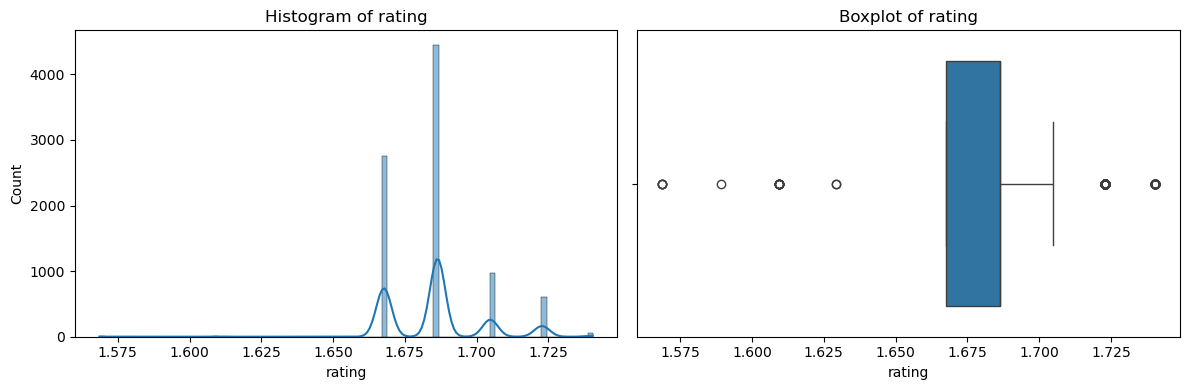

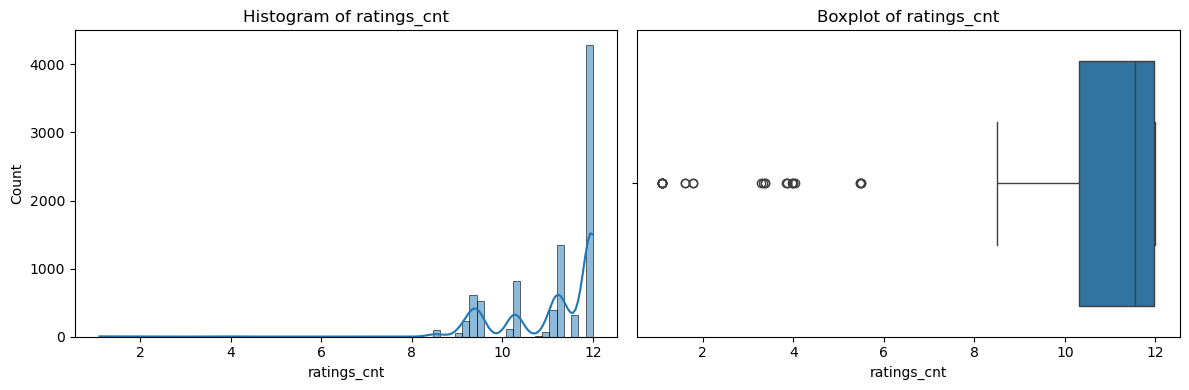

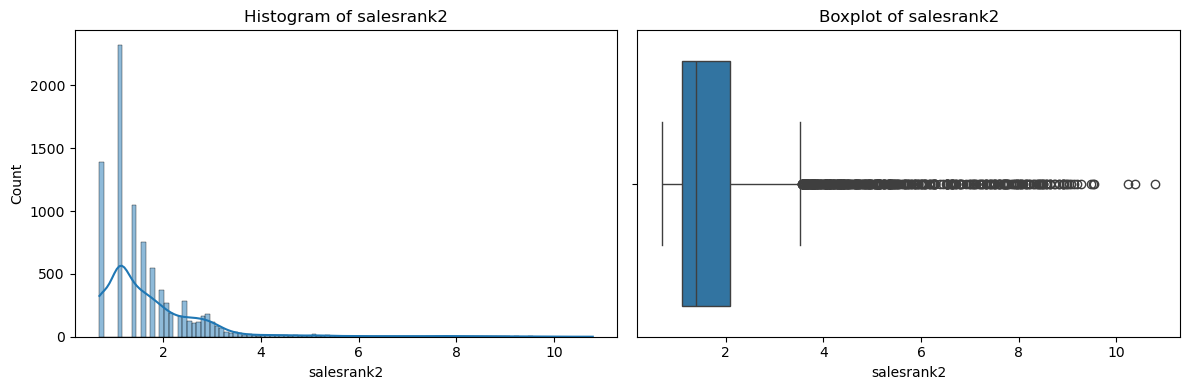

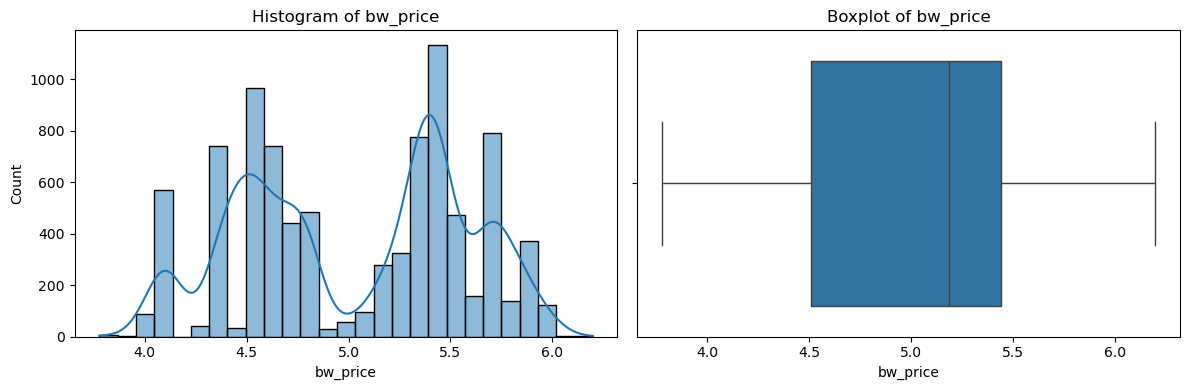

C:\ProgramData\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


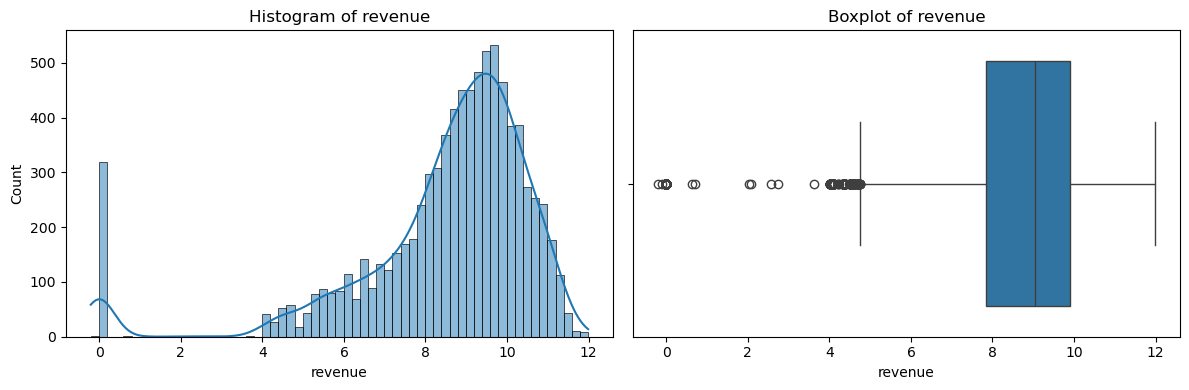

C:\ProgramData\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


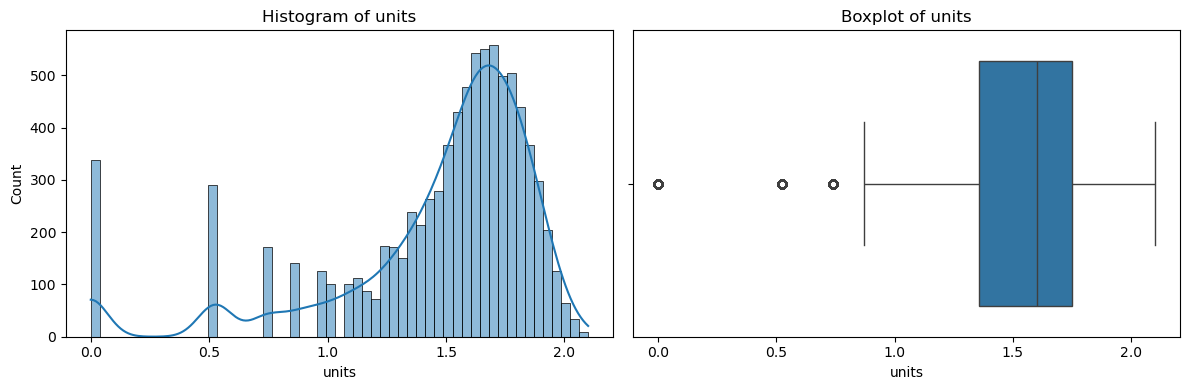

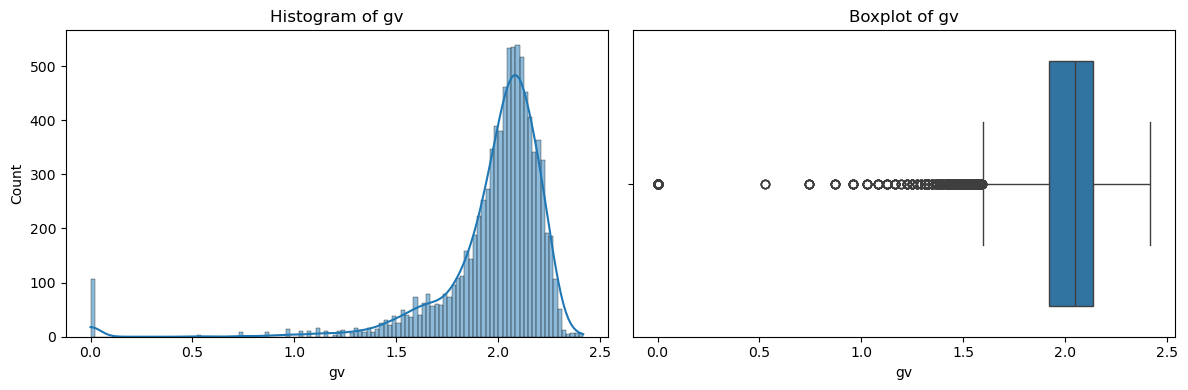

In [43]:
# 히스토그램 & 박스플롯 한꺼번에 그리기
for col in continuous_cols:
    # units, gv 컬럼만 로그 변환
   # if col in ['units', 'gv']:
    df[col] = np.log1p(df[col])  # log1p(x) = log(1+x), 0값 안전하게 처리
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # 히스토그램
    sns.histplot(df[col].dropna(), ax=axes[0], kde=True)
    axes[0].set_title(f'Histogram of {col}')
    
    # 박스플롯(사분위 그래프)
    sns.boxplot(x=df[col].dropna(), ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')
    
    plt.tight_layout()
    plt.show()

### 2. 시계열 그래프

In [108]:
#asins = df['asin'].unique()[:3]  # 많으면 너무 복잡하므로 일부만 예시
asins = ['B0CP1LR1PW','B0CKYZ3B83','B0CKZ1CK1H']
n_rows = len(asins)

cols_to_plot = ['rating', 'ratings_cnt', 'salesrank2', 'bw_price', 'units']

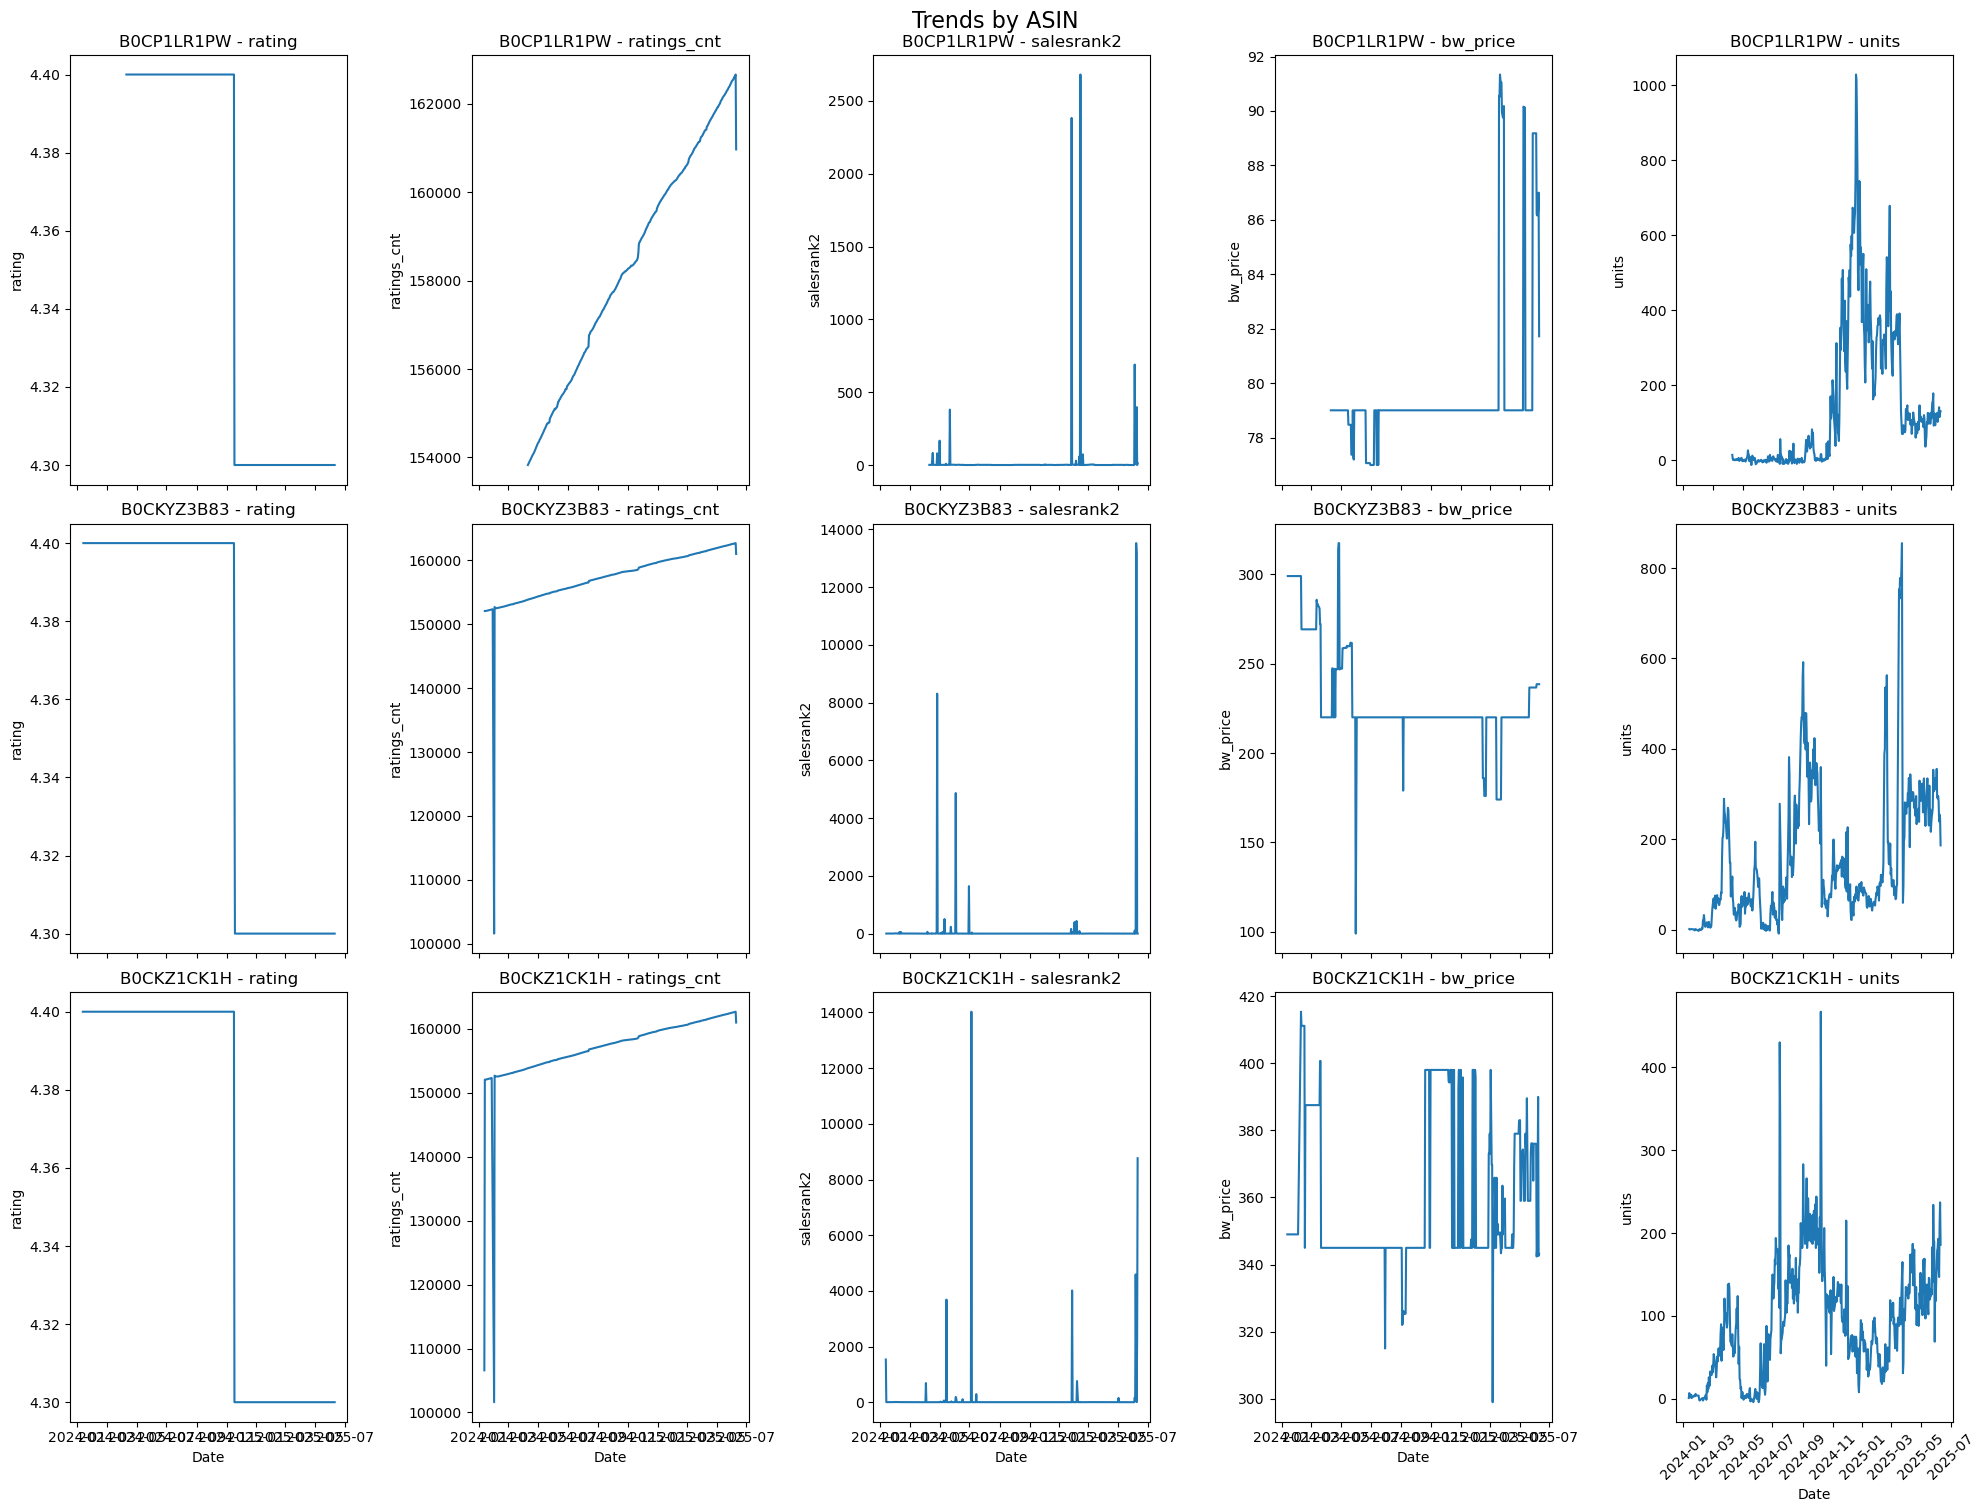

In [110]:
fig, axs = plt.subplots(n_rows, len(cols_to_plot), figsize=(20, 5 * n_rows), sharex='col')
axs = axs.reshape(n_rows, len(cols_to_plot))

for i, asin in enumerate(asins):
    sub_df = df[df['asin'] == asin].sort_values('crawl_date')
    for j, col in enumerate(cols_to_plot):
        ax = axs[i, j]
        sns.lineplot(data=sub_df, x='crawl_date', y=col, ax=ax)
        ax.set_title(f"{asin} - {col}")
        ax.set_xlabel("Date")
        ax.set_ylabel(col)
        
plt.tight_layout()
plt.xticks(rotation=45)
plt.subplots_adjust(top=0.95)
plt.suptitle("Trends by ASIN", fontsize=16)
plt.show()

### 3. 상관계수 히트맵 그리기

In [61]:
# Data Loading
df = pd.read_csv('amz_pdp_price_sales_gv_top20_0617.csv')

In [63]:
# 날짜 컬럼이 문자열인 경우 datetime으로 변환
df['crawl_date'] = pd.to_datetime(df['crawl_date'])
print(df)

     crawl_date        asin  rating  ratings_cnt  salesrank1  salesrank2  \
0    2024-01-12  B0CKZ1CK1H     4.4     106587.0     56478.0      1534.0   
1    2024-01-12  B0CKYY27YP     4.4     106587.0     18941.0         8.0   
2    2024-01-12  B0CKYYL8B9     4.4     106587.0   1836649.0      4905.0   
3    2024-01-13  B0CKZ1CK1H     4.4     152048.0       253.0         3.0   
4    2024-01-12  B0CKYZPPMJ     4.4     106587.0   1952729.0        80.0   
...         ...         ...     ...          ...         ...         ...   
8863 2025-06-12  B0CKZ1RXKH     4.3     160994.0        86.0         1.0   
8864 2025-06-13  B0CKYSMM1J     4.3      30261.0      2266.0        10.0   
8865 2025-06-13  B0CJ4N6S6S     4.5      67270.0      2053.0        11.0   
8866 2025-06-13  B0CP1LR1PW     4.3     161021.0        85.0         1.0   
8867 2025-06-13  B0CKYYYYYF     4.4      78216.0       400.0         4.0   

      salesrank3  bw_price   revenue  units      gv  
0            NaN    349.00    349

In [71]:
# gv와 units 합계
total_gv = df['gv'].sum()
total_units = df['units'].sum()

# 비율 계산
ratio = total_units / total_gv * 100
print(ratio)

6.291194974102865


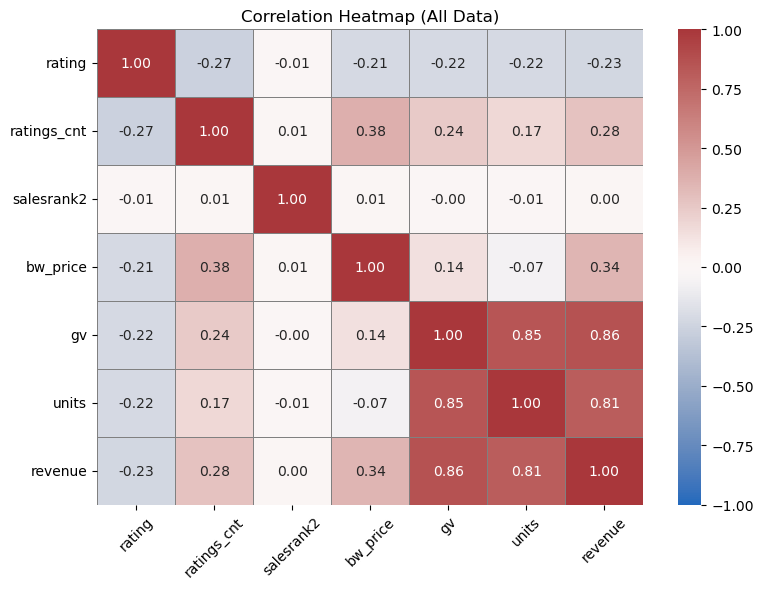

In [73]:
# 분석할 컬럼 선택
cols = ['rating', 'ratings_cnt', 'salesrank2', 'bw_price', 'gv', 'units', 'revenue']

# 전체 데이터의 상관계수 행렬 계산
corr = df[cols].corr()

# Heatmap 그리기
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='vlag',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='gray'
)
plt.title('Correlation Heatmap (All Data)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

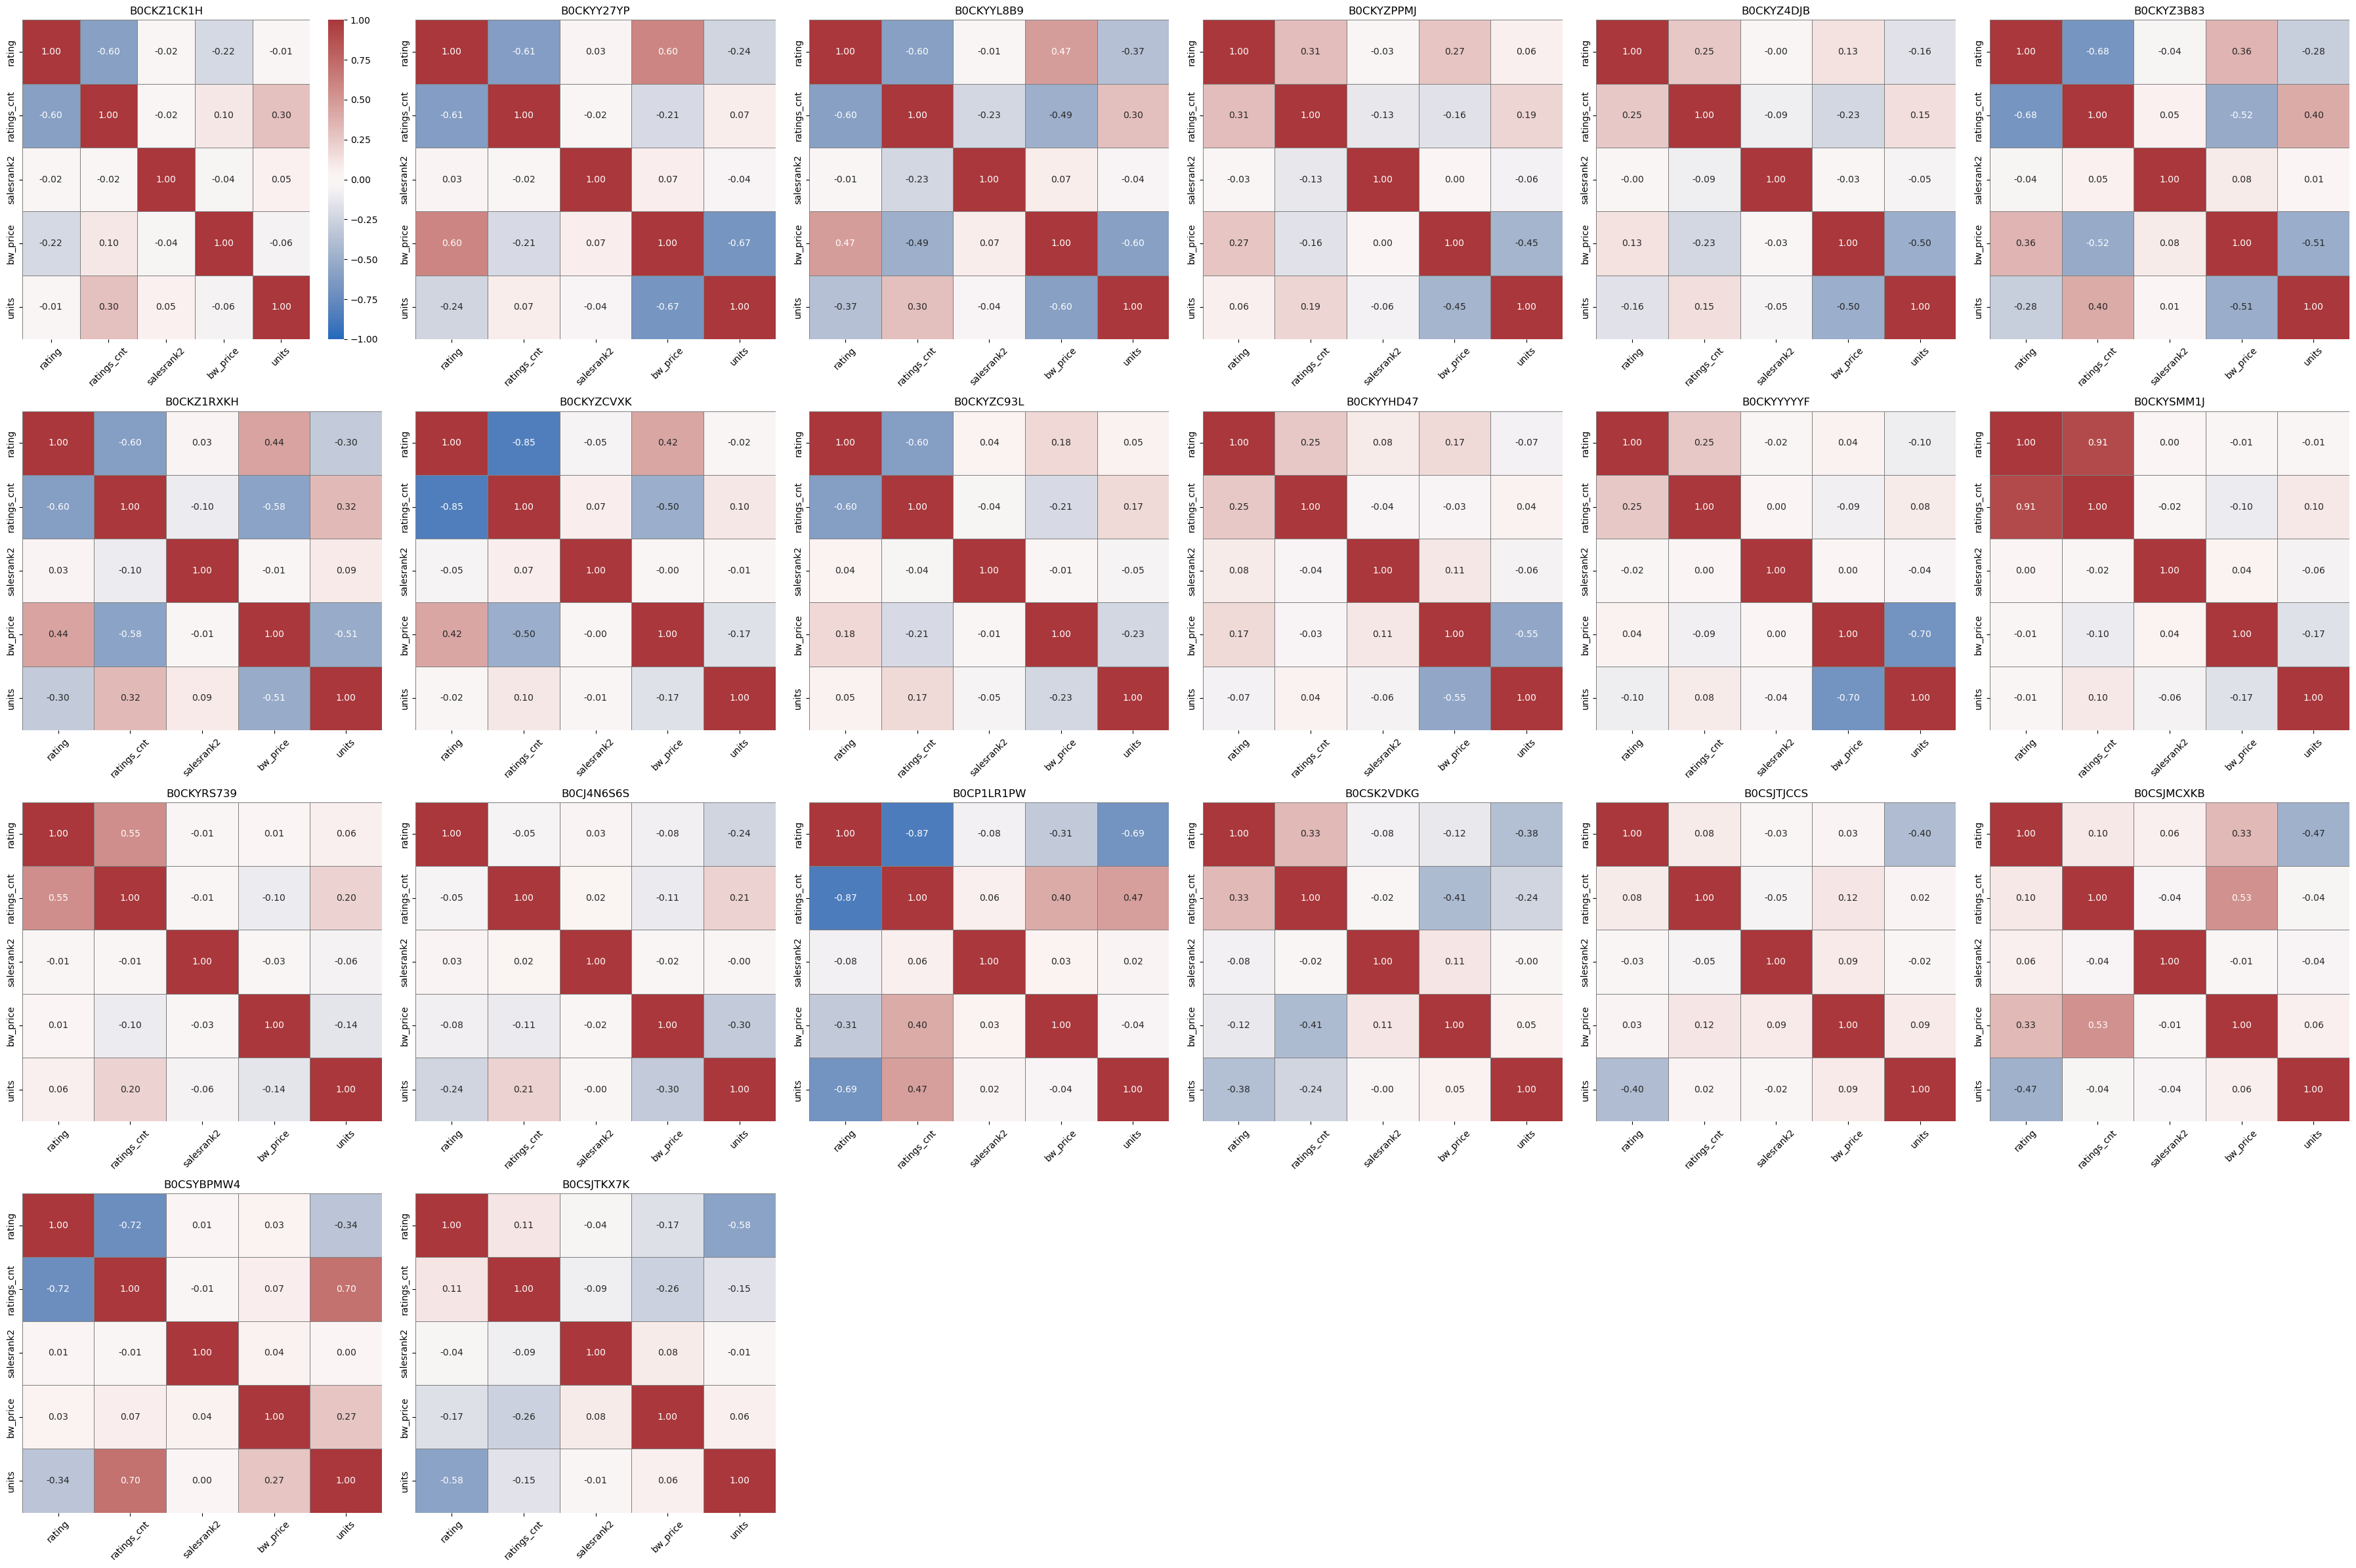

In [59]:
# ASIN 리스트 및 서브플롯 설정
cols = ['asin', 'rating', 'ratings_cnt', 'salesrank2', 'bw_price', 'units', 'gv']
asins = df['asin'].unique()
n = len(asins)
ncols = 6
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = axes.flatten()


# ASIN별 heatmap 그리기
for i, asin in enumerate(asins):
    sub = df[df['asin'] == asin]
    corr = sub[['rating', 'ratings_cnt', 'salesrank2', 'bw_price', 'units','gv']].corr()
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        ax=axes[i],
        cbar=i == 0,
        cmap='vlag',
        vmin=-1,
        vmax=1,
        linewidths=0.5,
        linecolor='gray'
    )
    axes[i].set_title(asin)
    axes[i].tick_params(axis='x', rotation=45)

# 남는 축 제거 및 레이아웃 조정
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()
plt.show()